# ✈️ DelayPredict — 03a Random Forest

**Goal:** Train a Random Forest classifier and compare it against the baseline (Logistic Regression).

This notebook is **self-contained** — it loads raw data and performs all feature engineering internally.  
No dependency on previous notebooks at runtime, except `baseline_metrics.csv` for the comparison table.

---
**Input:** `data/raw/airlines_delay.csv`  
**Input (optional):** `data/processed/baseline_metrics.csv` — for comparison against baseline  
**Output:** `models/rf_model.pkl`, `data/processed/rf_metrics.csv`  
**MLflow:** Run is logged automatically at the end of this notebook

## 1. Imports

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
import subprocess
subprocess.run(["pip", "install", "mlflow"], check=True)
import joblib
import mlflow
import mlflow.sklearn

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42  # fixed seed for reproducibility


## 2. Load Raw Data

This notebook always loads from the **raw dataset** and performs feature engineering itself.  
This keeps the notebook fully self-contained and independent of `01_eda.ipynb`.

In [89]:
RAW_PATH = Path("../data/raw/airlines_delay.csv")

if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Raw dataset not found at {RAW_PATH}.\n"
        "Please place airlines_delay.csv in data/raw/"
    )

df = pd.read_csv(RAW_PATH)

print("Source :", RAW_PATH)
print("Shape  :", df.shape)
display(df.head())


Source : ..\data\raw\airlines_delay.csv
Shape  : (539383, 9)


,id,Airline,Flight,AirportFrom,AirportTo,DayOfWeek,Time,Length,Delay
0,1,CO,269,SFO,IAH,3,15,205,1
1,2,US,1558,PHX,CLT,3,15,222,1
2,3,AA,2400,LAX,DFW,3,20,165,1
3,4,AA,2466,SFO,DFW,3,20,195,1
4,5,AS,108,ANC,SEA,3,30,202,0


## 3. Feature Engineering

All transformations are applied here from scratch — no dependency on the processed CSV.

| Raw Column | Action | Reason |
|---|---|---|
| `Time` | `// 60` → `DepartureHour` | Time is minutes since midnight (0–1439) |
| `id` | Drop | Row identifier, no signal |
| `Flight` | Drop | High cardinality, weak generalization |
| `Time` | Drop | Replaced by `DepartureHour` |
| `DayOfWeek` | Keep as-is | Treated as categorical in preprocessing |

In [90]:
# ── Derive DepartureHour from Time ──────────────────────────────────────────
# Time is stored as minutes since midnight (0 = 00:00, 1439 = 23:59)
df["DepartureHour"] = df["Time"] // 60

# ── Drop columns not used for modeling ──────────────────────────────────────
# id     : row identifier only
# Flight : 6,585 unique values — too high cardinality, poor generalization
# Time   : replaced by DepartureHour
DROP_COLS = ["id", "Flight", "Time"]
df = df.drop(columns=DROP_COLS)

print("Columns after feature engineering:", df.columns.tolist())
print("Shape:", df.shape)
display(df.head())


Columns after feature engineering: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'Delay', 'DepartureHour']
Shape: (539383, 7)


,Airline,AirportFrom,AirportTo,DayOfWeek,Length,Delay,DepartureHour
0,CO,SFO,IAH,3,205,1,0
1,US,PHX,CLT,3,222,1,0
2,AA,LAX,DFW,3,165,1,0
3,AA,SFO,DFW,3,195,1,0
4,AS,ANC,SEA,3,202,0,0


## 4. Features and Target

**Target:** `Delay` — 1 if the flight arrived more than 15 minutes late, 0 otherwise.

In [91]:
TARGET = "Delay"

X = df.drop(columns=[TARGET])  # feature matrix
y = df[TARGET]                  # target vector (0 = no delay, 1 = delay)

print("Features:", X.columns.tolist())
print("X shape :", X.shape)
print()

# Class distribution
dist = y.value_counts(normalize=True).mul(100).round(1).rename("% share")
print("Target distribution:")
display(dist)


Features: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Length', 'DepartureHour']
X shape : (539383, 6)

Target distribution:


Delay
0    55.5
1    44.5
Name: % share, dtype: float64

## 5. Feature Types

| Feature | Type | Preprocessing | Reason |
|---|---|---|---|
| Airline | Categorical | OneHotEncoder | 18 carriers |
| AirportFrom | Categorical | OneHotEncoder | 293 airports |
| AirportTo | Categorical | OneHotEncoder | 293 airports |
| DayOfWeek | Categorical | OneHotEncoder | No linear order for delay risk |
| Length | Numeric | None | Trees are scale-invariant — no StandardScaler needed |
| DepartureHour | Numeric | None | Trees are scale-invariant — no StandardScaler needed |

> **Key difference from baseline:** Random Forest does **not** require feature scaling.  
> Trees split on thresholds, so the absolute scale of numeric features does not matter.

In [92]:
# Categorical features → OneHotEncoding
CATEGORICAL = ["Airline", "AirportFrom", "AirportTo", "DayOfWeek"]

# Numeric features → passed through as-is (no scaling needed for tree models)
NUMERIC = ["Length", "DepartureHour"]

# Verify all expected features are present
assert all(f in X.columns for f in CATEGORICAL + NUMERIC), \
    "Feature mismatch — check dataset columns."

print("Categorical:", CATEGORICAL)
print("Numeric    :", NUMERIC)


Categorical: ['Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek']
Numeric    : ['Length', 'DepartureHour']


## 6. Train / Test Split

- **80 / 20** split — same ratio as baseline for a fair comparison
- `stratify=y` — preserves class ratio in both splits
- `random_state=42` — same seed as baseline for identical splits

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,  # ensures same class ratio in train and test
)

# Confirm delay rate is consistent across splits
print(f"Train: {X_train.shape}  |  delay rate: {y_train.mean():.3f}")
print(f"Test : {X_test.shape}   |  delay rate: {y_test.mean():.3f}")


Train: (431506, 6)  |  delay rate: 0.445
Test : (107877, 6)   |  delay rate: 0.445


## 7. Preprocessing Pipeline

Random Forest only needs OHE for categorical features.  
Numeric features are passed through unchanged — trees do not benefit from scaling.

In [94]:
preprocessor = ColumnTransformer(
    transformers=[
        # Numeric: passthrough — RF is invariant to feature scale
        ("num", "passthrough", NUMERIC),

        # Categorical: one-hot encode
        # handle_unknown="ignore" → unseen categories at inference produce all-zero row
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ],
    remainder="drop",  # drop any unlisted columns
)


## 8. Random Forest Model

**Why Random Forest?**
- Captures non-linear relationships that Logistic Regression cannot
- Robust to outliers and irrelevant features
- Built-in feature importance
- Good performance with default hyperparameters

**Hyperparameters (defaults — tuning in a later step if needed):**

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 100 | Standard starting point — good bias/variance trade-off |
| `max_depth` | None | Trees grow fully — let the model decide |
| `min_samples_split` | 2 | Default — no restriction on splitting |
| `class_weight` | None | 55/45 split is mild — no reweighting needed |
| `n_jobs` | -1 | Use all available CPU cores |

In [95]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,    # number of trees in the forest
        max_depth=35,      # trees grow until all leaves are pure (or min_samples)
        min_samples_split=2, # minimum samples required to split a node
        class_weight=None,   # no reweighting — target is only mildly imbalanced
        n_jobs=-1,           # parallelise across all CPU cores
        random_state=RANDOM_STATE,
    )),
])

rf_pipeline.fit(X_train, y_train)
print("Random Forest trained successfully.")


Random Forest trained successfully.


## 9. Evaluate

Evaluate Random Forest on the held-out test set and compare against the baseline.

In [96]:
y_pred_rf  = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]  # probability of delay

rf_metrics = {
    "Accuracy" : accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "Recall"   : recall_score(y_test, y_pred_rf, zero_division=0),
    "F1"       : f1_score(y_test, y_pred_rf, zero_division=0),
    "ROC-AUC"  : roc_auc_score(y_test, y_proba_rf),
}

print("Random Forest metrics:")
for k, v in rf_metrics.items():
    print(f"  {k:<10}: {v:.4f}")

print()
print(classification_report(
    y_test, y_pred_rf,
    target_names=["No Delay", "Delay"],
    zero_division=0
))


Random Forest metrics:
  Accuracy  : 0.6538
  Precision : 0.6699
  Recall    : 0.4391
  F1        : 0.5305
  ROC-AUC   : 0.7019

              precision    recall  f1-score   support

    No Delay       0.65      0.83      0.73     59824
       Delay       0.67      0.44      0.53     48053

    accuracy                           0.65    107877
   macro avg       0.66      0.63      0.63    107877
weighted avg       0.66      0.65      0.64    107877



## 10. Comparison Against Baseline

Load the baseline metrics saved by `02_baseline.ipynb` and add the Random Forest results.  
If the baseline CSV does not exist, only RF metrics are shown.

In [97]:
BASELINE_METRICS_PATH = Path("../data/processed/baseline_metrics.csv")

rf_row = {"model": "RandomForest", **rf_metrics}

if BASELINE_METRICS_PATH.exists():
    # Load Dummy + LR results from notebook 02 and append RF
    comparison_df = pd.read_csv(BASELINE_METRICS_PATH)
    comparison_df = pd.concat(
        [comparison_df, pd.DataFrame([rf_row])],
        ignore_index=True
    )
else:
    # Baseline CSV not available — show RF results only
    print("baseline_metrics.csv not found — showing RF results only.")
    print("Run 02_baseline.ipynb first for a full comparison.")
    comparison_df = pd.DataFrame([rf_row])

display(comparison_df.round(4))


,model,Accuracy,Precision,Recall,F1,ROC-AUC
0,DummyClassifier,0.5546,0.0000,0.0000,0.0000,0.5000
1,LogisticRegression,0.6464,0.6345,0.4862,0.5506,0.6921
2,RandomForest,0.6538,0.6699,0.4391,0.5305,0.7019


## 11. Confusion Matrix

- **True Negatives (top-left):** correctly predicted No Delay
- **False Positives (top-right):** predicted Delay, actually No Delay
- **False Negatives (bottom-left):** predicted No Delay, actually Delay ← the costly error
- **True Positives (bottom-right):** correctly predicted Delay

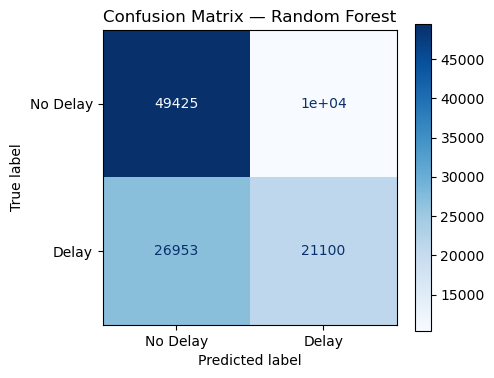

In [98]:
fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["No Delay", "Delay"],
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()


## 12. ROC Curve and Precision-Recall Curve

**ROC Curve** — AUC = 0.5 is random guessing. Higher is better.  
**Precision-Recall Curve** — the dashed line is the no-skill baseline (= delay rate in test set).

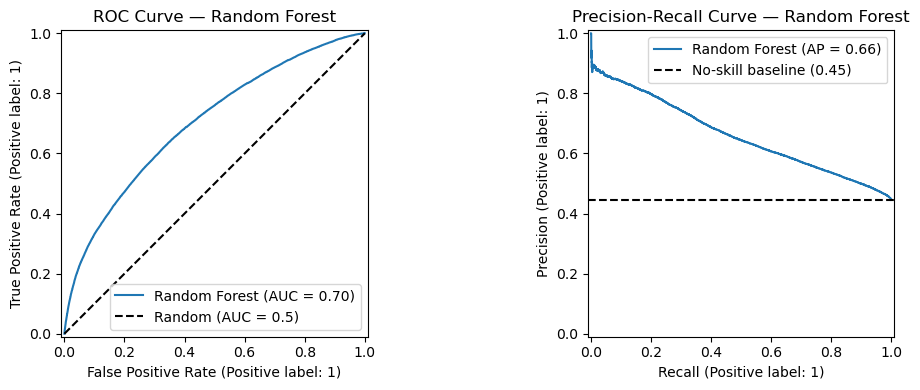

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=ax1, name="Random Forest")
ax1.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax1.set_title("ROC Curve — Random Forest")
ax1.legend()

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, ax=ax2, name="Random Forest")
ax2.axhline(y_test.mean(), color="k", linestyle="--",
            label=f"No-skill baseline ({y_test.mean():.2f})")
ax2.set_title("Precision-Recall Curve — Random Forest")
ax2.legend()

plt.tight_layout()
plt.show()


## 13. Feature Importance

Random Forest provides **built-in feature importance** based on the mean decrease in impurity  
across all trees. This is more robust than LR coefficients because it captures non-linear effects.

Higher importance = the feature contributes more to reducing uncertainty in predictions.

Top 20 most important features:


,Feature,Importance
0,DepartureHour,0.250399
1,Airline_WN,0.151158
2,Length,0.136143
3,DayOfWeek_4,0.019345
4,DayOfWeek_7,0.018977
5,DayOfWeek_5,0.018632
6,DayOfWeek_1,0.018478
7,DayOfWeek_2,0.018281
8,DayOfWeek_3,0.018248
9,DayOfWeek_6,0.015547


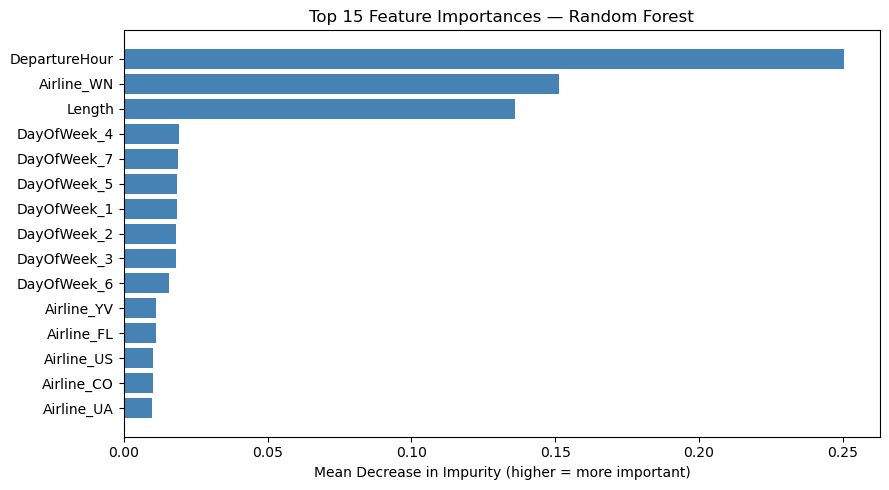

In [100]:
# Extract feature names after OHE transformation
ohe_names = (
    rf_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(CATEGORICAL)
    .tolist()
)
# Full feature name list: numeric first (passthrough order), then OHE
feature_names = NUMERIC + ohe_names
importances   = rf_pipeline.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": importances})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 most important features:")
display(importance_df.head(20))

# ── Bar chart: top 15 features ───────────────────────────────────────────────
top15 = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(9, 5))
plt.barh(top15["Feature"], top15["Importance"], color="steelblue")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Mean Decrease in Impurity (higher = more important)")
plt.tight_layout()
plt.show()


## 14. Predicted Probability Distribution

A well-calibrated model pushes probabilities toward 0 and 1 — clear separation between classes.  
Compare this to the Logistic Regression distribution from `02_baseline.ipynb`.

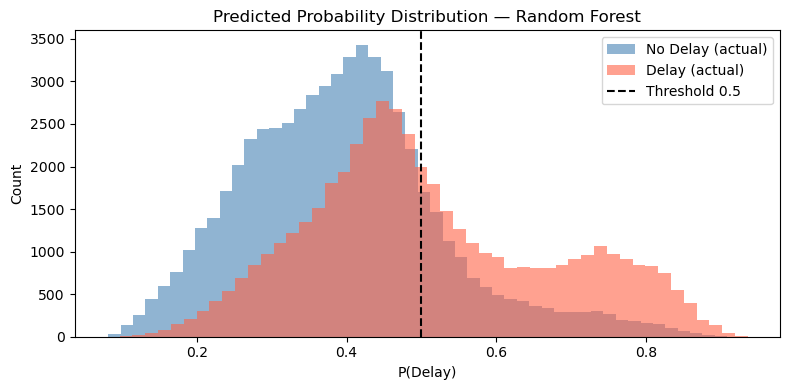

In [101]:
plt.figure(figsize=(8, 4))

# Distribution for correctly labeled non-delayed flights
plt.hist(y_proba_rf[y_test == 0], bins=50, alpha=0.6,
         label="No Delay (actual)", color="steelblue")

# Distribution for correctly labeled delayed flights
plt.hist(y_proba_rf[y_test == 1], bins=50, alpha=0.6,
         label="Delay (actual)", color="tomato")

# Default decision threshold
plt.axvline(0.5, color="black", linestyle="--", label="Threshold 0.5")

plt.title("Predicted Probability Distribution — Random Forest")
plt.xlabel("P(Delay)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Save Model and Metrics

- **Model** saved as `.pkl` for use in the FastAPI inference endpoint
- **Metrics CSV** saved for reference and MLflow logging

In [102]:
# ── Save trained model ───────────────────────────────────────────────────────
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "rf_model.pkl"
joblib.dump(rf_pipeline, MODEL_PATH)
print(f"Model saved   : {MODEL_PATH}")

# ── Save RF metrics CSV ───────────────────────────────────────────────────────
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rf_metrics_df = pd.DataFrame([{"model": "RandomForest", **rf_metrics}])
RF_METRICS_PATH = OUTPUT_DIR / "rf_metrics.csv"
rf_metrics_df.to_csv(RF_METRICS_PATH, index=False)
print(f"Metrics saved : {RF_METRICS_PATH}")


Model saved   : ..\models\rf_model.pkl
Metrics saved : ..\data\processed\rf_metrics.csv


## 16. MLflow Logging

Log this run to MLflow — parameters, metrics, and the trained model artifact are all recorded.  
After running this cell, start the MLflow UI with:
```
mlflow ui
```
Then open `http://localhost:5000` to compare all runs across notebooks.

In [103]:
# MLflow experiment — all notebooks log to the same experiment for easy comparison
mlflow.set_experiment("DelayPredict")

with mlflow.start_run(run_name="RandomForest_baseline"):

    # ── Log hyperparameters ──────────────────────────────────────────────────
    rf_clf = rf_pipeline.named_steps["classifier"]
    mlflow.log_params({
        "model"            : "RandomForest",
        "n_estimators"     : rf_clf.n_estimators,
        "max_depth"        : str(rf_clf.max_depth),   # None → string for MLflow
        "min_samples_split": rf_clf.min_samples_split,
        "class_weight"     : str(rf_clf.class_weight),
        "random_state"     : RANDOM_STATE,
        "train_size"       : X_train.shape[0],
        "test_size"        : X_test.shape[0],
        "features"         : ", ".join(CATEGORICAL + NUMERIC),
    })

    # ── Log evaluation metrics ───────────────────────────────────────────────
    mlflow.log_metrics({
        "accuracy" : rf_metrics["Accuracy"],
        "precision": rf_metrics["Precision"],
        "recall"   : rf_metrics["Recall"],
        "f1"       : rf_metrics["F1"],
        "roc_auc"  : rf_metrics["ROC-AUC"],
    })

    # ── Log model artifact ───────────────────────────────────────────────────
    mlflow.sklearn.log_model(rf_pipeline, artifact_path="model")

    print(f"MLflow run logged — experiment: 'DelayPredict'")
    print(f"Run name: RandomForest_baseline")
    print(f"Start MLflow UI with: mlflow ui")


2026/04/20 19:54:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/20 19:54:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged — experiment: 'DelayPredict'
Run name: RandomForest_baseline
Start MLflow UI with: mlflow ui


## 17. Summary

Final results across all models trained so far.

In [104]:
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"Train : {X_train.shape[0]:>7,} rows")
print(f"Test  : {X_test.shape[0]:>7,} rows")
print()

# Print comparison table — all models side by side
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
print(f"{'Model':<22}" + "".join(f"{m:>10}" for m in metric_cols))
print("-" * 72)
for _, row in comparison_df.iterrows():
    vals = "".join(f"{row[m]:>10.4f}" for m in metric_cols)
    print(f"{row['model']:<22}{vals}")

print()
print("Next: 03b_xgboost.ipynb — XGBoost vs. Random Forest vs. Baseline")


RANDOM FOREST RESULTS
Train : 431,506 rows
Test  : 107,877 rows

Model                   Accuracy Precision    Recall        F1   ROC-AUC
------------------------------------------------------------------------
DummyClassifier           0.5546    0.0000    0.0000    0.0000    0.5000
LogisticRegression        0.6464    0.6345    0.4862    0.5506    0.6921
RandomForest              0.6538    0.6699    0.4391    0.5305    0.7019

Next: 03b_xgboost.ipynb — XGBoost vs. Random Forest vs. Baseline
